<a href="https://colab.research.google.com/github/moanshori-zerone/WaterQualityAssest/blob/main/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving WQD.xlsx to WQD.xlsx
User uploaded file "WQD.xlsx" with length 925902 bytes


In [ ]:
import pandas as pd

df = pd.read_excel('WQD.xlsx')
display(df.head())

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Temp,4300.0,25.695663,9.670202,0.194046,19.775926,25.041849,30.277718,84.251522
Turbidity (cm),4300.0,39.046681,20.942726,0.051424,22.224140,30.205696,55.945735,99.797743
DO(mg/L),4300.0,5.300346,1.832736,0.133928,3.978366,5.000754,6.521225,14.970122
BOD (mg/L),4300.0,3.125079,2.292060,1.000621,1.522077,2.236022,4.324578,14.943006
CO2,4300.0,6.375929,2.831104,0.001155,5.048761,6.598076,8.241532,14.984216
pH`,4300.0,7.713468,1.580282,0.003944,6.443019,7.743176,9.035251,14.851195
Alkalinity (mg L-1 ),4300.0,93.717183,68.949048,25.012328,40.422364,67.562607,132.834386,299.913160
Hardness (mg L-1 ),4300.0,127.055476,78.883091,0.255805,69.479620,111.063301,162.675648,398.796550
Calcium (mg L-1 ),4300.0,84.871932,75.718842,0.018293,23.745078,62.845419,115.596833,399.321398
Ammonia (mg L-1 ),4300.0,0.048269,0.122886,0.000001,0.012750,0.026335,0.039016,0.999300


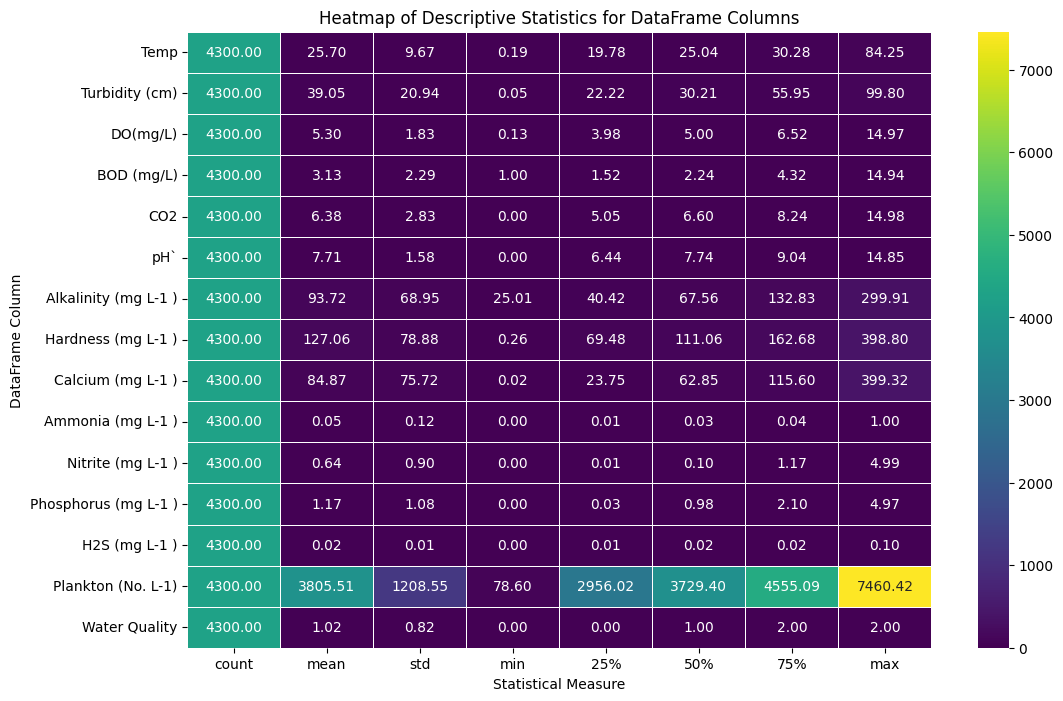

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get descriptive statistics and transpose for better visualization
df_desc = df.describe().T

# Create a heatmap of the descriptive statistics
plt.figure(figsize=(12, 8))
sns.heatmap(df_desc, annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Heatmap of Descriptive Statistics for DataFrame Columns')
plt.xlabel('Statistical Measure')
plt.ylabel('DataFrame Column')
plt.show()

### Visualizing Outliers using Violin Plots

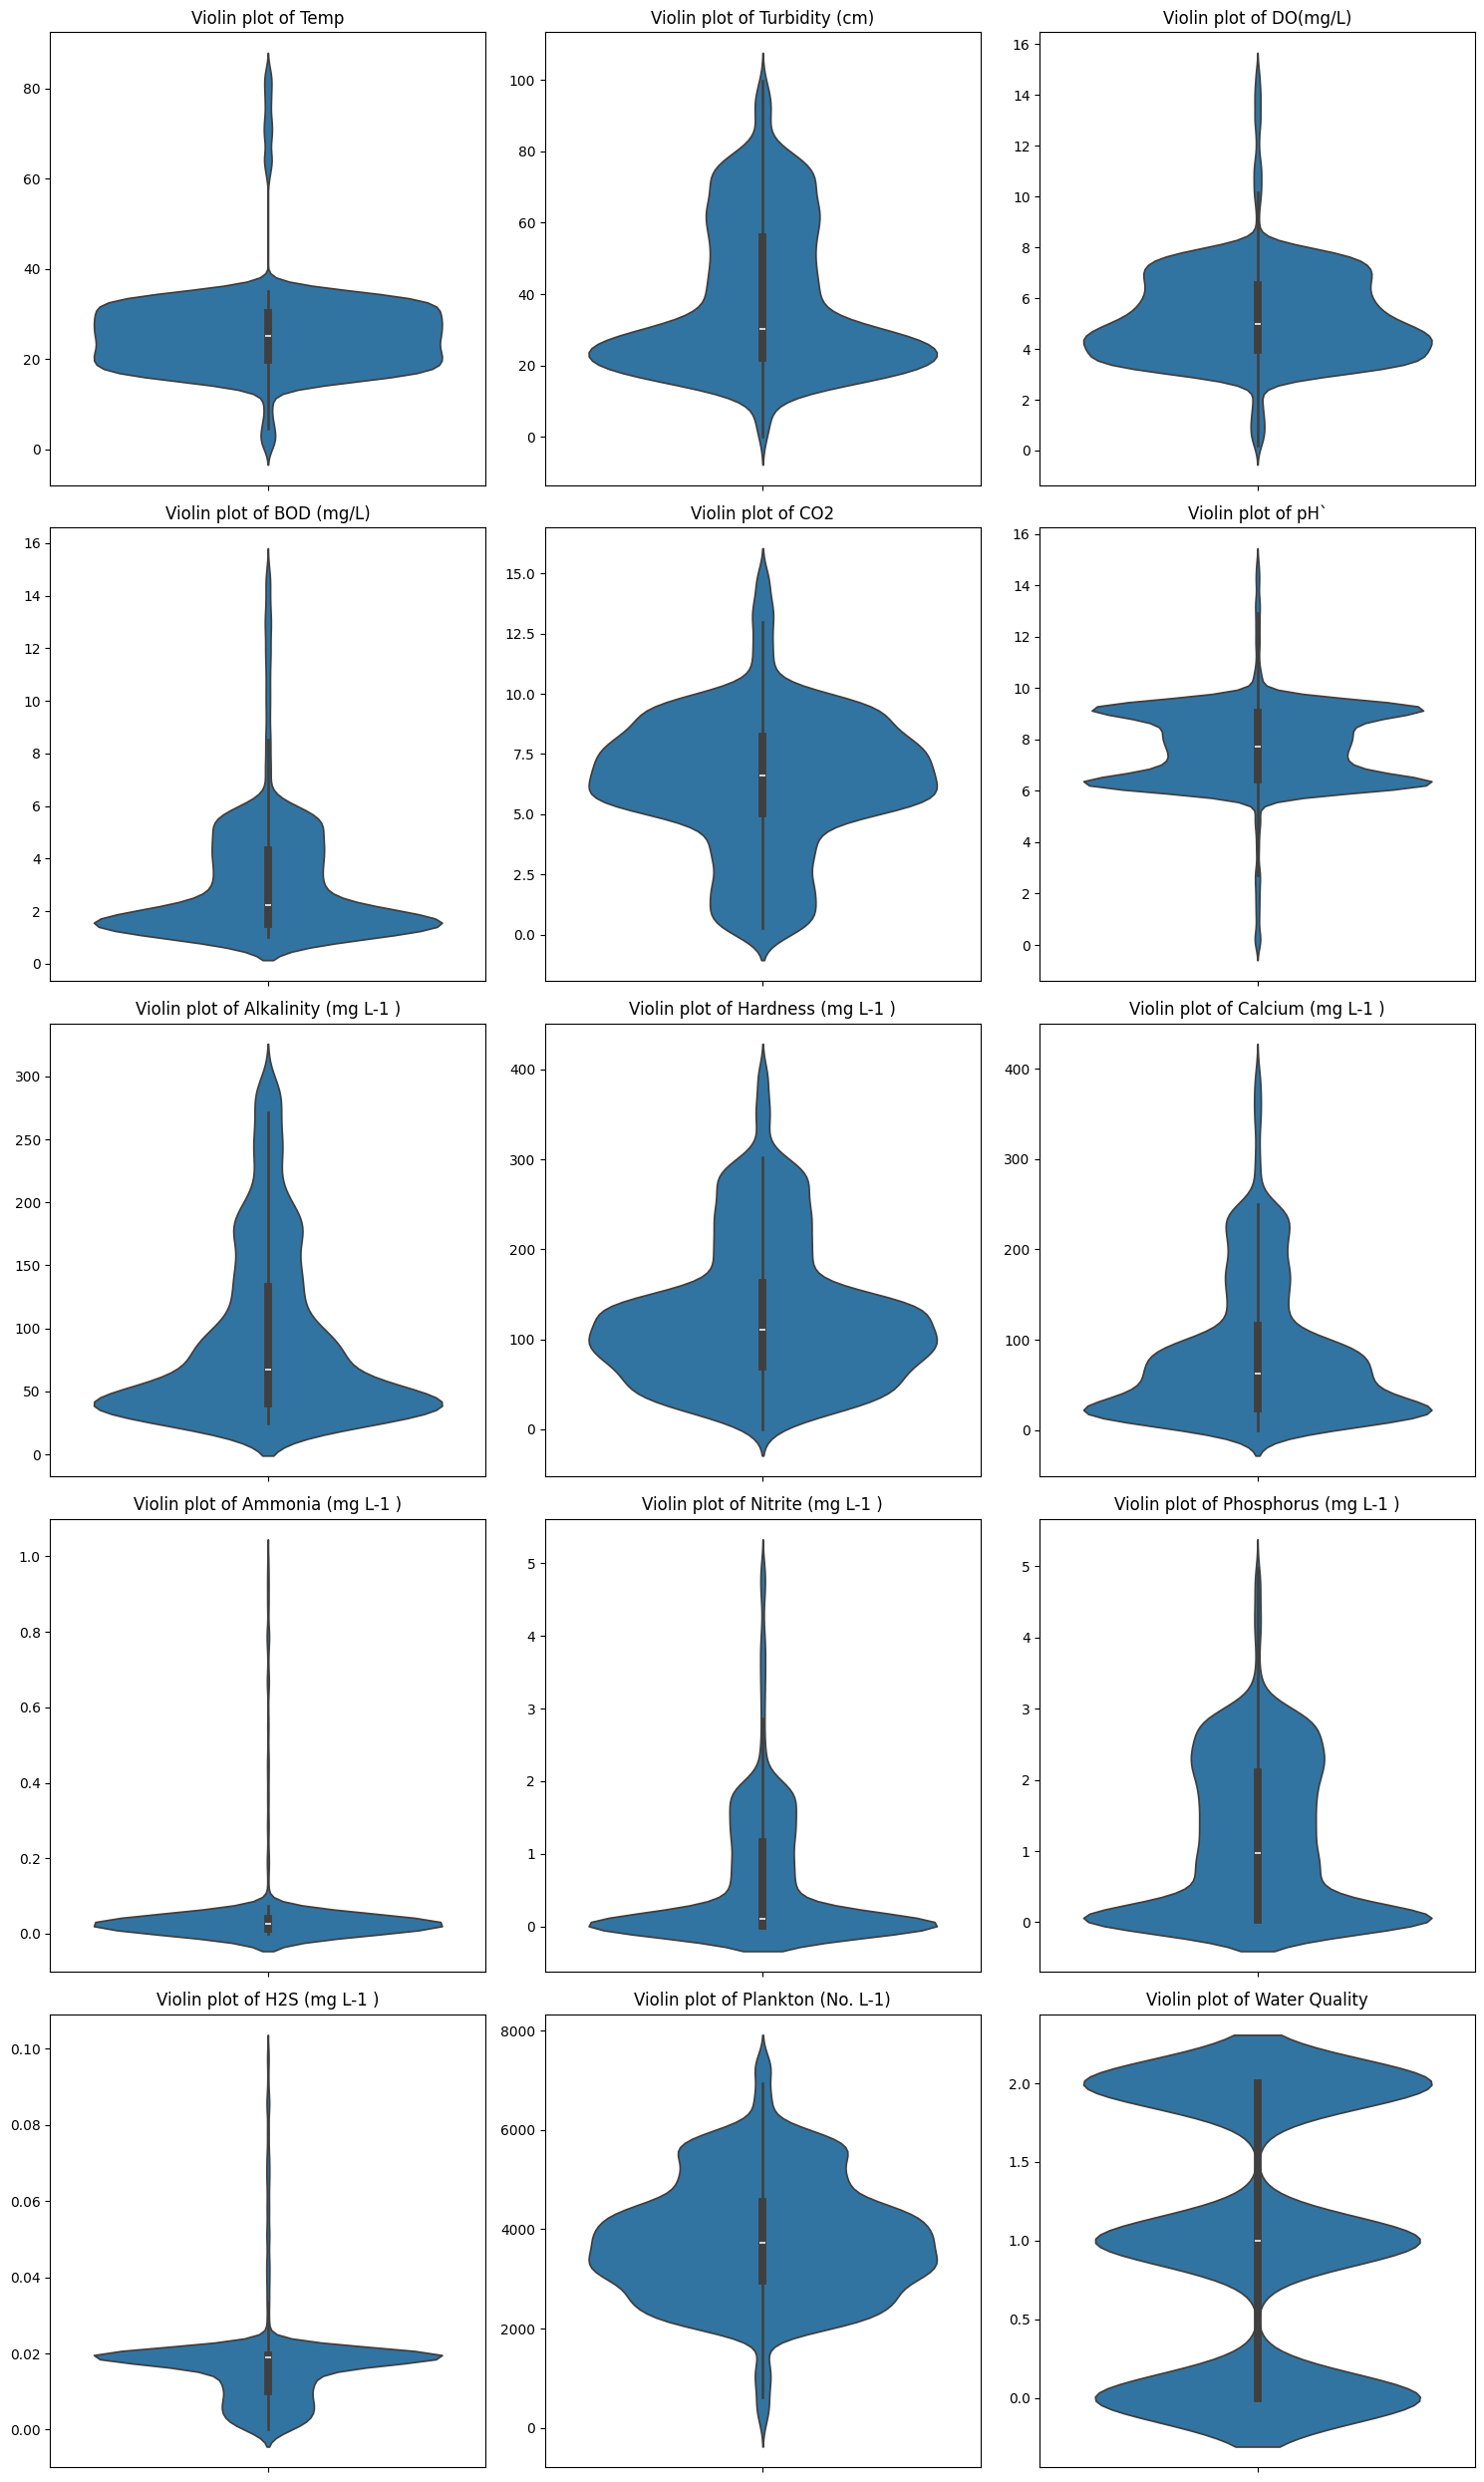

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for violin plotting
numeric_cols = df.select_dtypes(include=['number']).columns

# Determine the number of rows and columns for the subplot grid
# Aim for 3 columns per row for better readability
num_cols_per_row = 3
num_rows = (len(numeric_cols) + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.violinplot(y=df[col])
    plt.title(f'Violin plot of {col}')
    plt.ylabel('') # Remove y-axis label to avoid clutter

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Assuming 'y' is already defined from df['Water Quality']
# If not, ensure it's defined: y = df['Water Quality']

# Define the mapping from numerical labels to categorical names
quality_mapping = {
    0: 'Excellent',
    1: 'Good',
    2: 'Poor'
}

y = df['Water Quality']

# Create a new Series 'y_categorical' by mapping the values
y_categorical = y.map(quality_mapping)

print("Head of the new categorical 'Water Quality' Series:")
display(y_categorical.head())

print("Value counts of the new categorical 'Water Quality' Series:")
display(y_categorical.value_counts())

Head of the new categorical 'Water Quality' Series:


,Water Quality
0,Poor
1,Poor
2,Poor
3,Poor
4,Poor


Value counts of the new categorical 'Water Quality' Series:


,count
Water Quality,
Poor,1500
Good,1400
Excellent,1400


In [ ]:
import matplotlib.pyplot as plt

# y = df['Water Quality']

# Get the value counts for the 'Water Quality' column
water_quality_counts = y_categorical.value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(water_quality_counts, labels=water_quality_counts.index, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Distribution of Water Quality Categories')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("Count of each Water Quality category:")
display(water_quality_counts)

NameError: name 'y_categorical' is not defined

In [ ]:
print(f"Shape of DataFrame before outlier removal: {df.shape}")

# Select only numeric columns for outlier removal
numeric_cols = df.select_dtypes(include=['number']).columns

# Remove outliers using the IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Shape of DataFrame after outlier removal: {df.shape}")
display(df.head())

Shape of DataFrame before outlier removal: (4300, 15)
Shape of DataFrame after outlier removal: (3102, 15)


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
111,12.257485,29.766348,6.084959,3.397404,9.214851,9.477810,40.709355,21.568500,121.935632,0.044443,1.610510,2.198595,0.013431,5509.063323,2
124,4.967443,20.963078,5.905563,2.738017,8.218755,9.436380,32.228340,197.488194,20.477560,0.034409,0.713203,2.502017,0.005873,5574.504767,2
129,9.379408,21.090956,7.544240,4.185231,1.282818,9.223327,171.144119,168.481737,21.329691,0.038211,0.175674,0.023222,0.009317,5517.948835,2
144,6.596582,26.033492,7.317996,2.859827,4.240880,9.488383,176.376358,34.511103,18.071020,0.041754,0.790023,2.741278,0.000222,2759.130360,2
148,5.859256,21.393544,6.892223,5.149949,9.698864,6.365248,128.533713,65.275700,168.468429,0.043180,1.351001,0.011600,0.008210,5998.797865,2


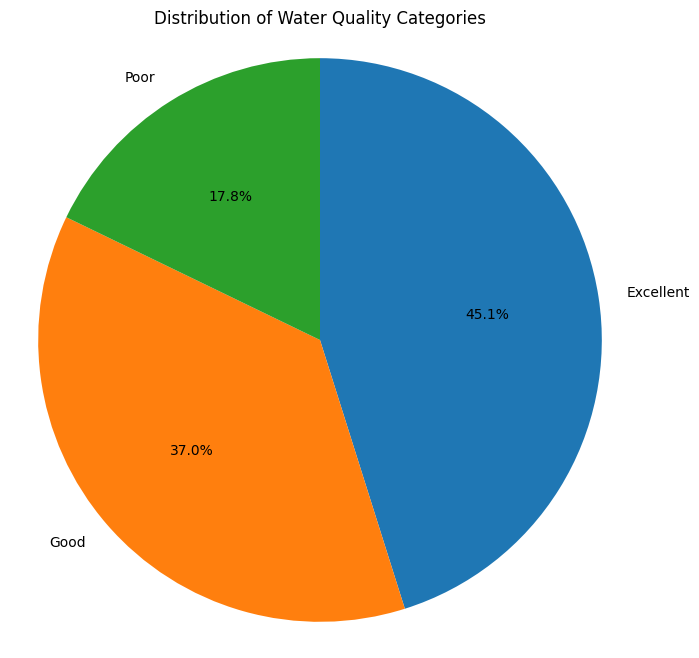

Count of each Water Quality category:


,count
Water Quality,
Excellent,1400
Good,1149
Poor,553


In [ ]:
import matplotlib.pyplot as plt

y = df['Water Quality']
y_categorical = y.map(quality_mapping)

# Get the value counts for the 'Water Quality' column
water_quality_counts = y_categorical.value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(water_quality_counts, labels=water_quality_counts.index, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Distribution of Water Quality Categories')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("Count of each Water Quality category:")
display(water_quality_counts)

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# Initialize the MinMaxScaler
scaler = StandardScaler()

# Select only numeric columns for scaling, excluding 'Water Quality'
numeric_cols_to_scale = df.select_dtypes(include=['number']).columns.drop('Water Quality', errors='ignore')

# Apply Min-Max normalization to the selected numeric columns
df[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])

print("DataFrame after Min-Max Normalization:")
display(df.head())

DataFrame after Min-Max Normalization:


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
111,-2.206741,-0.509951,0.656913,0.478918,1.215919,1.396788,-0.760921,-1.524579,0.927971,1.449931,1.720635,1.067427,-0.249410,1.644414,2
124,-3.482935,-0.938964,0.536150,0.046241,0.802162,1.362869,-0.923109,1.224864,-0.927270,0.750937,0.351495,1.369667,-1.455181,1.707379,2
129,-2.710577,-0.932732,1.639245,0.995875,-2.078876,1.188439,1.733473,0.771523,-0.911688,1.015781,-0.468685,-1.099473,-0.905646,1.652964,2
144,-3.197738,-0.691866,1.486946,0.126171,-0.850161,1.405445,1.833533,-1.322299,-0.971276,1.262565,0.468709,1.607996,-2.356570,-1.001422,2
148,-3.326814,-0.917986,1.200332,1.628905,1.416968,-1.151514,0.918605,-0.841480,1.778860,1.361951,1.324668,-1.111050,-1.082280,2.115610,2


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Water Quality', axis=1)
# y = df['Water Quality']

X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, stratify=y, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2481, 14)
Shape of X_test: (621, 14)
Shape of y_train: (2481,)
Shape of y_test: (621,)


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import numpy as np

# Get unique class names for confusion matrix labels
class_names = np.unique(y_test)

# Initialize LDA and QDA models
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis(tol=0.00001)

# Train LDA model
print("\n--- Training Linear Discriminant Analysis (LDA) ---")
lda.fit(X_train, y_train)

# Predict with LDA
y_pred_lda = lda.predict(X_test)

# Evaluate LDA
print("\nLDA Classification Report:")
print(classification_report(y_test, y_pred_lda, digits=4))
print("\nLDA Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lda), index=class_names, columns=class_names))

# Train QDA model
print("\n--- Training Quadratic Discriminant Analysis (QDA) ---")
qda.fit(X_train, y_train)

# Predict with QDA
y_pred_qda = qda.predict(X_test)

# Evaluate QDA
print("\nQDA Classification Report:")
print(classification_report(y_test, y_pred_qda, digits=4))
print("\nQDA Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_qda), index=class_names, columns=class_names))


--- Training Linear Discriminant Analysis (LDA) ---

LDA Classification Report:
              precision    recall  f1-score   support

   Excellent     0.8805    1.0000    0.9365       280
        Good     0.8814    0.9696    0.9234       230
        Poor     0.8600    0.3874    0.5342       111

    accuracy                         0.8792       621
   macro avg     0.8740    0.7857    0.7980       621
weighted avg     0.8772    0.8792    0.8597       621


LDA Confusion Matrix:


,Excellent,Good,Poor
Excellent,280,0,0
Good,0,223,7
Poor,38,30,43



--- Training Quadratic Discriminant Analysis (QDA) ---

QDA Classification Report:
              precision    recall  f1-score   support

   Excellent     0.9241    1.0000    0.9605       280
        Good     0.9237    1.0000    0.9603       230
        Poor     1.0000    0.6216    0.7667       111

    accuracy                         0.9324       621
   macro avg     0.9493    0.8739    0.8958       621
weighted avg     0.9375    0.9324    0.9258       621


QDA Confusion Matrix:


,Excellent,Good,Poor
Excellent,280,0,0
Good,0,230,0
Poor,23,19,69


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Define the cross-validation strategy
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n--- Cross-validation for Linear Discriminant Analysis (LDA) ---")
lda_scores = cross_val_score(lda, X, y, cv=skf, scoring='accuracy')
print(f"LDA Cross-validation Accuracy: {lda_scores}")
print(f"LDA Mean CV Accuracy: {np.mean(lda_scores):.4f} (+/- {np.std(lda_scores):.4f})")

print("\n--- Cross-validation for Quadratic Discriminant Analysis (QDA) ---")
qda_scores = cross_val_score(qda, X, y, cv=skf, scoring='accuracy')
print(f"QDA Cross-validation Accuracy: {qda_scores}")
print(f"QDA Mean CV Accuracy: {np.mean(qda_scores):.4f} (+/- {np.std(qda_scores):.4f})")


--- Cross-validation for Linear Discriminant Analysis (LDA) ---


NameError: name 'lda' is not defined

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

for i in range (10, 110, 10):
  for j in range (100, 1100, 100):

    mlp = MLPClassifier(hidden_layer_sizes=(i, ), activation='relu', solver='adam', max_iter=j, random_state=42)

    print("\n--- Training Multi-Layer Perceptron (MLP) Classifier ---")
    # Train the model
    %time mlp.fit(X_train, y_train)

    # Predict on the test set
    y_pred_mlp = mlp.predict(X_test)
    accuracy_score(y_test, y_pred_mlp)
    print('hn lay1= ', i, ' epoch = ', j, ' accuracy = ', accuracy_score(y_test, y_pred_mlp))


--- Training Multi-Layer Perceptron (MLP) Classifier ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


CPU times: user 965 ms, sys: 586 µs, total: 966 ms
Wall time: 1.07 s
hn lay1=  10  epoch =  100  accuracy =  0.8985507246376812

--- Training Multi-Layer Perceptron (MLP) Classifier ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


CPU times: user 1.94 s, sys: 4.54 ms, total: 1.94 s
Wall time: 2.2 s
hn lay1=  10  epoch =  200  accuracy =  0.9130434782608695

--- Training Multi-Layer Perceptron (MLP) Classifier ---


...

CPU times: user 2.29 s, sys: 12 µs, total: 2.29 s
Wall time: 2.18 s
hn lay1=  100  epoch =  200  accuracy =  0.9516908212560387

--- Training Multi-Layer Perceptron (MLP) Classifier ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


CPU times: user 3.4 s, sys: 2.96 ms, total: 3.41 s
Wall time: 3.35 s
hn lay1=  100  epoch =  300  accuracy =  0.9500805152979066

--- Training Multi-Layer Perceptron (MLP) Classifier ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


CPU times: user 5.25 s, sys: 6.66 ms, total: 5.26 s
Wall time: 5.31 s
hn lay1=  100  epoch =  400  accuracy =  0.9549114331723028

--- Training Multi-Layer Perceptron (MLP) Classifier ---
CPU times: user 5.45 s, sys: 3.02 ms, total: 5.45 s
Wall time: 5.34 s
hn lay1=  100  epoch =  500  accuracy =  0.9549114331723028

--- Training Multi-Layer Perceptron (MLP) Classifier ---
CPU times: user 6.46 s, sys: 7.86 ms, total: 6.47 s
Wall time: 6.44 s
hn lay1=  100  epoch =  600  accuracy =  0.9549114331723028

--- Training Multi-Layer Perceptron (MLP) Classifier ---
CPU times: user 5.46 s, sys: 7 ms, total: 5.47 s
Wall time: 5.37 s
hn lay1=  100  epoch =  700  accuracy =  0.9549114331723028

--- Training Multi-Layer Perceptron (MLP) Classifier ---
CPU times: user 6.31 s, sys: 9.86 ms, total: 6.32 s
Wall time: 6.28 s
hn lay1=  100  epoch =  800  accuracy =  0.9549114331723028

--- Training Multi-Layer Perceptron (MLP) Classifier ---
CPU times: user 5.42 s, sys: 2 ms, total: 5.42 s
Wall time: 5.3

In [ ]:
class_names

array(['Excellent', 'Good', 'Poor'], dtype=object)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from sklearn.metrics import accuracy_score
import numpy as np

# Get unique class names for confusion matrix labels
# class_names = np.unique(y_test)
# class_names = np.unique(y_test)

# Initialize the MLPClassifier
# You can tune hyperparameters like hidden_layer_sizes, activation, solver, alpha, and max_iter
mlp = MLPClassifier(hidden_layer_sizes=(60, 60), activation='relu', solver='adam', max_iter=400, random_state=42)

print("\n--- Training Multi-Layer Perceptron (MLP) Classifier ---")
# Train the model
%time mlp.fit(X_train, y_train)

# Predict on the test set
y_pred_mlp = mlp.predict(X_test)

# Evaluate the model
print("\nMLP Classification Report:")
print(classification_report(y_test, y_pred_mlp, digits=4))
print("\nMLP Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_mlp), index=class_names, columns=class_names))
print('acc:', accuracy_score(y_test, y_pred_mlp))


--- Training Multi-Layer Perceptron (MLP) Classifier ---
CPU times: user 16.4 s, sys: 21.3 ms, total: 16.4 s
Wall time: 14.8 s

MLP Classification Report:
              precision    recall  f1-score   support

   Excellent     0.9859    1.0000    0.9929       280
        Good     0.9456    0.9826    0.9638       230
        Poor     0.9592    0.8468    0.8995       111

    accuracy                         0.9662       621
   macro avg     0.9636    0.9432    0.9521       621
weighted avg     0.9662    0.9662    0.9654       621


MLP Confusion Matrix:


,Excellent,Good,Poor
Excellent,280,0,0
Good,0,226,4
Poor,4,13,94


acc: 0.966183574879227


# Task
Generate and plot the confusion matrix, Receiver Operating Characteristic (ROC) curve, and Precision-Recall (PR) curve for each class of the best-performing MLP model.

## confusion_matrix_plot

### Subtask:
Generate and plot the confusion matrix for the best-performing MLP model.


**Reasoning**:
I need to generate and plot the confusion matrix for the MLP model. I will reuse the `y_pred_mlp` obtained from the model trained with `hidden_layer_sizes=(60,)` and `max_iter=400` in the previous step, as it was the best performing one. I will then convert the confusion matrix to a DataFrame and plot it as a heatmap with appropriate labels and title.



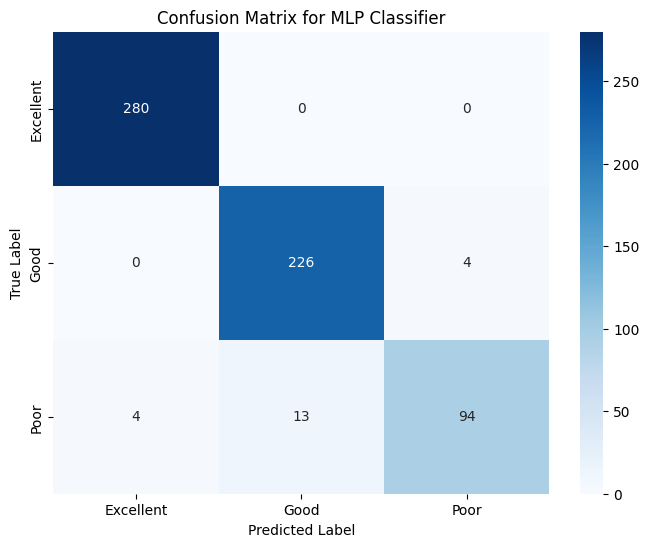

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
import numpy as np

# Get unique class names for confusion matrix labels
class_names = np.unique(y_test)

# Generate the confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

# Create a Pandas DataFrame from the confusion matrix with class names
cm_df_mlp = pd.DataFrame(cm_mlp, index=class_names, columns=class_names)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df_mlp, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for MLP Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

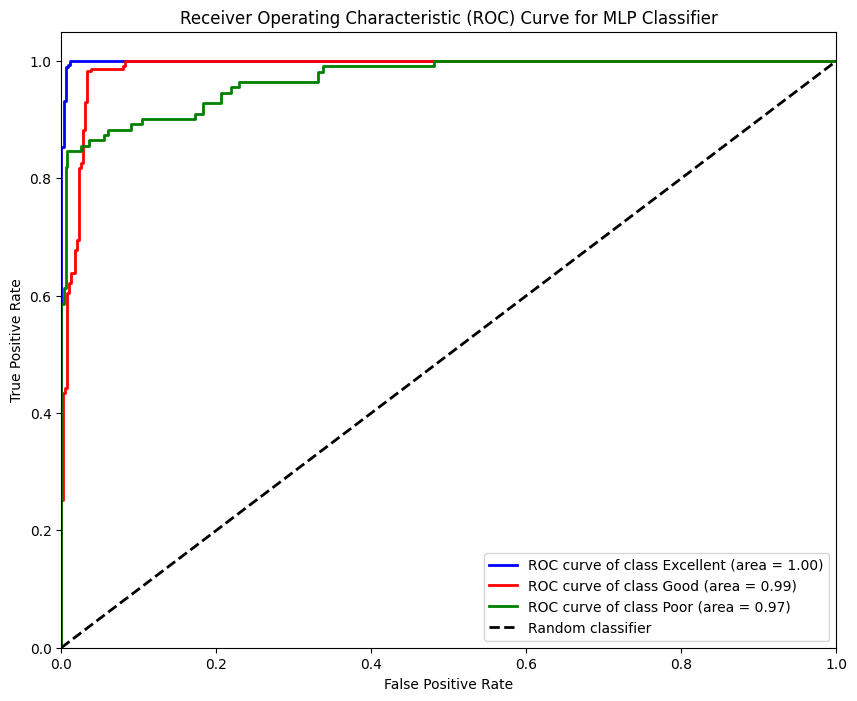

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
from sklearn.neural_network import MLPClassifier

# Re-initialize and train the best-performing MLPClassifier model
mlp = MLPClassifier(hidden_layer_sizes=(60, 60), activation='relu', solver='adam', max_iter=400, random_state=42)
mlp.fit(X_train, y_train)

# Get the probability scores for each class
y_score_mlp = mlp.predict_proba(X_test)

# Binarize the true labels for multiclass ROC calculation (one-vs-rest)
n_classes = len(np.unique(y_test))
# n_classes = np.unique(y_test)
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score_mlp[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan'] # Define more colors if needed

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for MLP Classifier')
plt.legend(loc="lower right")
plt.show()


**Reasoning**:
Now that the ROC curve has been plotted, I need to generate and plot the Precision-Recall (PR) curve for each class of the best-performing MLP model. This involves calculating probability scores, binarizing the true labels, computing the precision, recall, and average precision for each class, and finally plotting these curves.



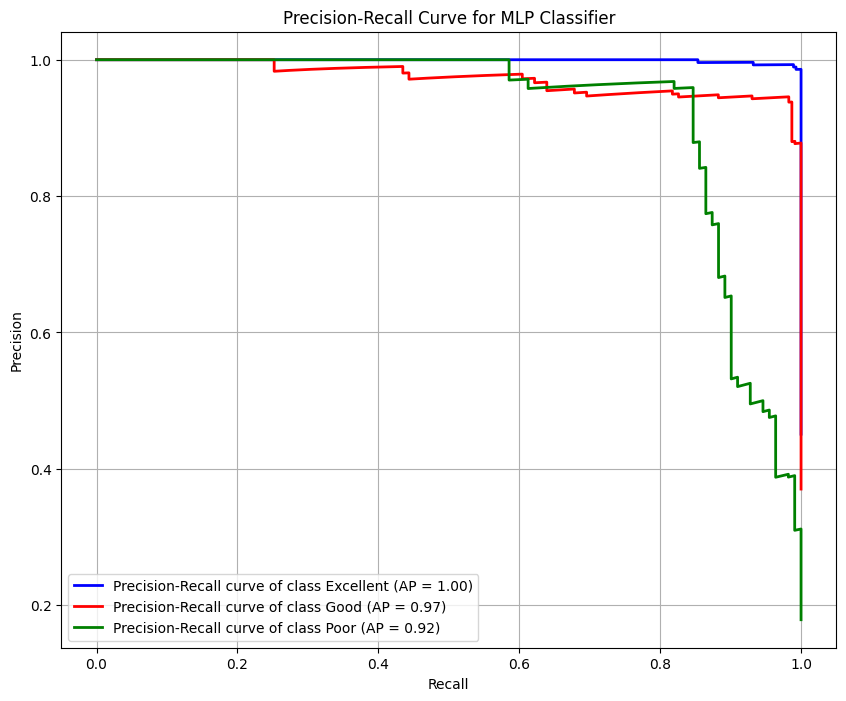

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Compute Precision-Recall curve and Average Precision for each class
precision = dict()
recall = dict()
avg_precision = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_binarized[:, i], y_score_mlp[:, i])
    avg_precision[i] = average_precision_score(y_test_binarized[:, i], y_score_mlp[:, i])

# Plot the Precision-Recall curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan'] # Define more colors if needed

for i in range(n_classes):
    plt.plot(recall[i], precision[i], color=colors[i], lw=2,
             label='Precision-Recall curve of class {0} (AP = {1:0.2f})'.format(class_names[i], avg_precision[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for MLP Classifier')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()